# Constraint Satisfaction Problem : Graph coloring


## Create Data

We can create a planar graph with $n$ vertices by randomly placing $n$ points in 2-dimensional Euclidean space and then performing a [Delaunay triangulation](https://en.wikipedia.org/wiki/Delaunay_triangulation).

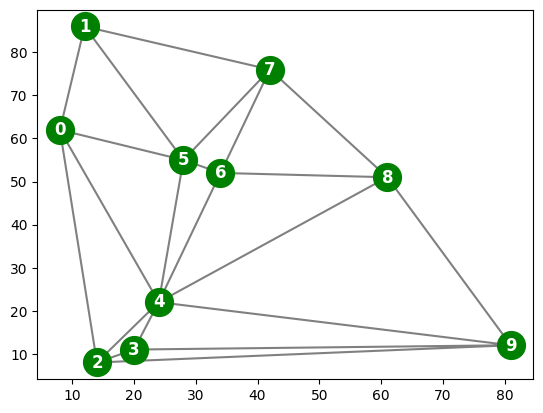

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

np.random.seed(1111)

# create points and sort them by
n = 10
points = np.random.randint(100, size=(n, 2))
o = np.argsort(points[:,0])
points = points[o,:]


# triangulate
tri = Delaunay(points)


# plot
plt.triplot(points[:,0], points[:,1], tri.simplices, color = "gray")
plt.plot(points[:,0], points[:,1], 'o', color = "green", markersize = 20)

for i in range(len(points)):
       plt.annotate(i, points[i,:],
        color='white', fontsize="large", weight='heavy',
        horizontalalignment='center', verticalalignment='center')

plt.show()

The triangulation can be converted into a list with an array of neighbor vertex indices for each point (see man page for [scipy.spatial.Delaunay](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.Delaunay.html)).

In [ ]:
(indptr, indices) = tri.vertex_neighbor_vertices

neighbors = []

for k in range(len(indptr)-1):
    neighbors.append(np.sort(indices[indptr[k]:indptr[k+1]]))

neighbors

[array([1, 2, 4, 5], dtype=int32),
 array([0, 5, 7], dtype=int32),
 array([0, 3, 4, 9], dtype=int32),
 array([2, 4, 9], dtype=int32),
 array([0, 2, 3, 5, 6, 8, 9], dtype=int32),
 array([0, 1, 4, 6, 7], dtype=int32),
 array([4, 5, 7, 8], dtype=int32),
 array([1, 5, 6, 8], dtype=int32),
 array([4, 6, 7, 9], dtype=int32),
 array([2, 3, 4, 8], dtype=int32)]

The first row are the indices for the points neighboring point 0.

## Define CSP

The problem is defined as a dictionary with variable names, a dictionary with domain values for each variable and a set of binary  not-equal constraints (tuples of variables that are not allowed to have the same value).  

In [ ]:
variables = [str(var) for var in range(n)]

domain = ['red', 'blue', 'green', 'orange']
#domain = ['red', 'blue', 'green']
domains = {}
for v in variables:
    domains[v] = domain

# create binary constraints
constraints = {}
for i in range(len(neighbors)):
    for j in neighbors[i]:
        if(i<j): constraints[tuple([str(i), str(j)])] = True
constraints = constraints.keys()

csp = {'variables': variables, 'domains': domains, 'constraints': constraints, }
csp

{'variables': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
 'domains': {'0': ['red', 'blue', 'green', 'orange'],
  '1': ['red', 'blue', 'green', 'orange'],
  '2': ['red', 'blue', 'green', 'orange'],
  '3': ['red', 'blue', 'green', 'orange'],
  '4': ['red', 'blue', 'green', 'orange'],
  '5': ['red', 'blue', 'green', 'orange'],
  '6': ['red', 'blue', 'green', 'orange'],
  '7': ['red', 'blue', 'green', 'orange'],
  '8': ['red', 'blue', 'green', 'orange'],
  '9': ['red', 'blue', 'green', 'orange']},
 'constraints': dict_keys([('0', '1'), ('0', '2'), ('0', '4'), ('0', '5'), ('1', '5'), ('1', '7'), ('2', '3'), ('2', '4'), ('2', '9'), ('3', '4'), ('3', '9'), ('4', '5'), ('4', '6'), ('4', '8'), ('4', '9'), ('5', '6'), ('5', '7'), ('6', '7'), ('6', '8'), ('7', '8'), ('8', '9')])}

## Check Completeness and Consistency

`assignment` is a dictionary. Assigned variables have an entry with the variable name as the key. `{}` is therefore the empty assignment.

In [ ]:
def complete(assignment, csp):
    return(all([v in assignment.keys() for v in csp['variables']]))

print("complete({}, csp) =", complete({}, csp))

print("complete({...complete list...}, csp) =",
      complete({'0': 'red', '1': 'red', '2': 'red', '3': 'red', '4': 'red',
          '5': 'red', '6': 'red', '7': 'red', '8': 'red', '9': 'red'}, csp))

complete({}, csp) = False
complete({...complete list...}, csp) = True


In [ ]:
def consistent(assignment, csp):
    for constr in csp['constraints']:
        if(constr[0] in assignment.keys() and constr[1] in assignment.keys()):
            if assignment[constr[0]] == assignment[constr[1]]: return(False)

    return(True)

print("consistent({}, csp) =", consistent({}, csp))
print("consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp) =",
      consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp))

consistent({}, csp) = True
consistent({'0': 'red', '1': 'red', '2': 'blue'}, csp) = False


## Implement Simple Backtracking Search

In [ ]:
# TODO: implement variable ordering. Choose variable with the minimum-remaining-values (MRV)
def select_unassigned_var(assignment, csp):
    if(complete(assignment, csp)): return(None)

    return(csp['variables'][np.where([not v in assignment.keys() for v in csp['variables']])[0][0]])

print("select_unassigned_var({'0': 'red', '1': 'blue'}, csp) =",
     select_unassigned_var({'0': 'red', '1': 'blue'}, csp))

select_unassigned_var({'0': 'red', '1': 'blue'}, csp) = 2


In [ ]:
# I use a global variable to turn on verbose mode in the recursion
#VERBOSE = True
VERBOSE = False
COUNT = 0

# returns None for failure
def backtrack_search(csp):
    global COUNT
    COUNT = 0

    assignment = backtrack({}, csp)

    print(f"Checked nodes: {COUNT}")

    return assignment

def backtrack(assignment, csp):
    global VERBOSE, COUNT

    COUNT += 1

    if complete(assignment, csp):
        return assignment

    var = select_unassigned_var(assignment, csp)

    # TODO: implement value ordering. Use the least-constraining-vaue heuristic.
    # for val in order_domain(assignment, var, csp)
    for val in csp['domains'][var]:
        assignment[var] = val

        if VERBOSE: print(f"Checking: {assignment}")

        if consistent(assignment, csp):

            #TODO: add inference for early failing (forward checking, )
            # if inference_fails(assignment, csp): return(None)
            result = backtrack(assignment, csp)
            if not result is None:
                    return(result)

        del assignment[var]

    if verbose: print(f"Backtracking")
    return(None)

## Run Backtracking Search on the Random Problem

In [ ]:
%timeit -n1 -r1 display(backtrack_search(csp))

Checked nodes: 11


{'0': 'red',
 '1': 'blue',
 '2': 'blue',
 '3': 'red',
 '4': 'green',
 '5': 'orange',
 '6': 'red',
 '7': 'green',
 '8': 'blue',
 '9': 'orange'}

3.9 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


Plot the resulting coloring

Checked nodes: 11


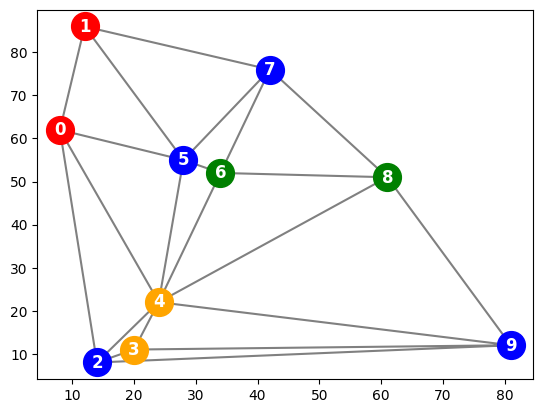

In [ ]:
result = backtrack_search(csp)

plt.triplot(points[:,0], points[:,1], tri.simplices, color = "gray")


for i in range(len(points)):
        plt.plot(points[i,0], points[i,1], 'o', color=list(res.values())[i], markersize=20)
        plt.annotate(i, points[i,:],
        color='white', fontsize="large", weight='heavy',
        horizontalalignment='center', verticalalignment='center')

plt.show()

## Assignment

Implement the following graph coloring algorithms:

* Add variable and value ordering to the implementation.
* Add forward checking to the implementation.
* Implement hill climbing local search with the min-conflicts heuristic.

Try to color graphs of several sizes with 3 and 4 colors. For each $n$, generate several random instances, and try to make n as large as you can manage. On average, how many constraints (edges) do your map coloring instances have for each $n$? Report the performance of each search algorithm as a function of $n$. For both variants of backtracking search, you can characterize performance in terms of the number of variable assignments attempted. For hill climbing search, report the number of uphill moves and random restarts required in order to reach a solution. Of course, you can also report raw running times as a function of $n$.

In [ ]:
import time
import random
import numpy as np
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import copy

# ---------- Utilities to build graph from Delaunay triangulation ----------
def build_delaunay_graph(n, seed=None, boundary_box=100):
    """Return points, neighbors list (adjacency list) for n random points."""
    if seed is not None:
        np.random.seed(seed)
    points = np.random.randint(boundary_box, size=(n, 2))
    # sort by x for nicer triangulation determinism
    o = np.argsort(points[:, 0])
    points = points[o, :]

    tri = Delaunay(points)
    indptr, indices = tri.vertex_neighbor_vertices
    neighbors = []
    for k in range(len(indptr) - 1):
        neighbors.append(np.sort(indices[indptr[k]:indptr[k + 1]]).tolist())
    # ensure symmetric
    for i, neigh in enumerate(neighbors):
        for j in neigh:
            if i not in neighbors[j]:
                neighbors[j].append(i)
    neighbors = [sorted(list(set(nb))) for nb in neighbors]
    return points, neighbors

def build_csp_from_neighbors(neighbors, colors):
    n = len(neighbors)
    variables = [str(i) for i in range(n)]
    domains = {v: list(colors) for v in variables}
    constraints = set()
    for i in range(n):
        for j in neighbors[i]:
            if i < j:
                constraints.add((str(i), str(j)))
    csp = {'variables': variables, 'domains': domains, 'constraints': constraints, 'neighbors': neighbors}
    return csp

In [ ]:
# ---------- Complete and consistent ----------
def complete(assignment, csp):
    return all(v in assignment for v in csp['variables'])

def consistent(assignment, csp):
    # binary not-equal constraints
    for (a, b) in csp['constraints']:
        if a in assignment and b in assignment:
            if assignment[a] == assignment[b]:
                return False
    return True

In [ ]:
# ---------- Variable ordering: MRV ----------
def select_unassigned_var_mrv(assignment, csp, current_domains=None):
    # current_domains: dict var -> domain (for forward checking)
    unassigned = [v for v in csp['variables'] if v not in assignment]
    if not unassigned:
        return None
    if current_domains is None:
        # simple: choose in order (fallback)
        return unassigned[0]
    # MRV: choose var with minimum remaining values; tie-breaker: degree heuristic (most neighbors)
    sizes = [(len(current_domains[v]), -len(csp['neighbors'][int(v)]), v) for v in unassigned]
    sizes.sort()
    return sizes[0][2]

In [ ]:
# ---------- Value ordering: LCV ----------
def order_domain_lcv(var, assignment, csp, current_domains=None):
    # For each value, count how many values it would rule out in neighbors (the lower the better)
    domain = current_domains[var] if current_domains is not None else csp['domains'][var]
    scores = []
    for val in domain:
        conflicts = 0
        for nb in csp['neighbors'][int(var)]:
            nbv = str(nb)
            if nbv not in assignment:
                # count how many values in nb's domain would be incompatible
                dom = current_domains[nbv] if current_domains is not None else csp['domains'][nbv]
                if val in dom:
                    conflicts += 1
            else:
                if assignment[nbv] == val:
                    conflicts += 1000  # big penalty - immediate conflict
        scores.append((conflicts, val))
    scores.sort(key=lambda x: (x[0], x[1]))
    return [v for (_, v) in scores]

In [ ]:
# ---------- Forward checking ----------
def forward_checking_inference(var, value, current_domains, csp):
    # current_domains is mutated shallow-copy by caller
    removed = []  # list of (var, val) removed
    for nb in csp['neighbors'][int(var)]:
        nbv = str(nb)
        if value in current_domains[nbv]:
            current_domains[nbv].remove(value)
            removed.append((nbv, value))
            if len(current_domains[nbv]) == 0:
                # failure: domain wiped out
                return False, removed
    return True, removed

In [ ]:
# ---------- Backtracking search with options ----------
def backtracking_search(csp, use_mrv=True, use_lcv=True, use_forward_checking=True, verbose=False, max_nodes=10_000_00):
    """
    Returns (assignment, stats)
    stats: dict with 'nodes', 'time', 'failed' (bool)
    """
    nodes = 0
    start = time.time()
    # initial domains copy
    initial_domains = {v: list(dom) for v, dom in csp['domains'].items()}
    assignment = {}
    result = None

    def backtrack(assignment, current_domains):
        nonlocal nodes, result
        nodes += 1
        if nodes > max_nodes:
            return None  # abort
        if complete(assignment, csp):
            return dict(assignment)
        var = select_unassigned_var_mrv(assignment, csp, current_domains) if use_mrv else \
              (next((v for v in csp['variables'] if v not in assignment), None))
        order = order_domain_lcv(var, assignment, csp, current_domains) if use_lcv else list(current_domains[var])
        for val in order:
            assignment[var] = val
            if verbose:
                print("Try", var, val)
            # check immediate consistency with already assigned neighbors
            ok = True
            for nb in csp['neighbors'][int(var)]:
                nbv = str(nb)
                if nbv in assignment and assignment[nbv] == val:
                    ok = False
                    break
            if not ok:
                del assignment[var]
                continue
            # forward checking
            removed = []
            if use_forward_checking:
                # make a local copy of domains for recursion
                # We will mutate the copy
                success, removed = forward_checking_inference(var, val, current_domains, csp)
                if not success:
                    # undo removals
                    for (rvar, rval) in removed:
                        current_domains[rvar].append(rval)
                    del assignment[var]
                    continue
            # recurse with current_domains (already mutated)
            res = backtrack(assignment, current_domains)
            if res is not None:
                return res
            # undo forward checking changes
            if use_forward_checking:
                for (rvar, rval) in removed:
                    current_domains[rvar].append(rval)
            del assignment[var]
        return None

    # call backtrack with a deep copy of domains
    res = backtrack(assignment, {v: list(dom) for v, dom in initial_domains.items()})
    end = time.time()
    stats = {'nodes': nodes, 'time': end - start, 'failed': res is None}
    return res, stats

In [ ]:
# ---------- Min-conflicts (hill-climbing) ----------
def min_conflicts(csp, max_steps=100000, max_restarts=50, verbose=False):
    """
    Returns (assignment, stats)
    stats includes 'steps', 'restarts', 'time', 'uphill_moves', 'failed'
    uphill_moves: number of moves that increased or did not decrease conflict count (heuristic tracking)
    """
    n = len(csp['variables'])
    variables = csp['variables']

    def conflict_count_for_var(var, value, assignment):
        count = 0
        for nb in csp['neighbors'][int(var)]:
            nbv = str(nb)
            if assignment.get(nbv) == value:
                count += 1
        return count

    start_time = time.time()
    steps = 0
    restarts = 0
    uphill_moves = 0

    for restart in range(max_restarts):
        restarts += 1
        # initialize assignment randomly
        assignment = {}
        for v in variables:
            assignment[v] = random.choice(csp['domains'][v])
        # compute conflicts
        def total_conflicts(assign):
            s = 0
            for (a, b) in csp['constraints']:
                if assign[a] == assign[b]:
                    s += 1
            return s

        conflicts = total_conflicts(assignment)
        if verbose:
            print("Restart", restart, "initial conflicts:", conflicts)
        if conflicts == 0:
            end_time = time.time()
            return assignment, {'steps': 0, 'restarts': restarts, 'time': end_time - start_time, 'uphill_moves': 0, 'failed': False}
        for step in range(max_steps):
            steps += 1
            if conflicts == 0:
                end_time = time.time()
                return assignment, {'steps': steps, 'restarts': restarts, 'time': end_time - start_time, 'uphill_moves': uphill_moves, 'failed': False}
            # pick a conflicted variable at random
            conflicted_vars = []
            for (a, b) in csp['constraints']:
                if assignment[a] == assignment[b]:
                    conflicted_vars.extend([a, b])
            if not conflicted_vars:
                conflicts = total_conflicts(assignment)
                continue
            var = random.choice(conflicted_vars)
            # pick value minimizing conflicts (tie break randomly)
            domain = csp['domains'][var]
            best_val = None
            best_conf = None
            for val in domain:
                c = conflict_count_for_var(var, val, assignment)
                if best_conf is None or c < best_conf:
                    best_conf = c
                    best_val = [val]
                elif c == best_conf:
                    best_val.append(val)
            chosen_val = random.choice(best_val)
            old_conf = conflict_count_for_var(var, assignment[var], assignment)
            new_conf = best_conf
            # if move does not decrease conflict count, consider it uphill
            if new_conf >= old_conf:
                uphill_moves += 1
            assignment[var] = chosen_val
            # update conflicts quickly (recompute total)
            conflicts = total_conflicts(assignment)
        # if reach here, this restart failed — try new restart
    end_time = time.time()
    return None, {'steps': steps, 'restarts': restarts, 'time': end_time - start_time, 'uphill_moves': uphill_moves, 'failed': True}

# ---------- Experiment runner ----------
def run_experiment(n_list, instances_per_n=5, colors_list=[3,4], seed_base=0, verbose=False):
    results = []
    for n in n_list:
        for colors in colors_list:
            for inst in range(instances_per_n):
                seed = seed_base + inst + n*100
                points, neighbors = build_delaunay_graph(n, seed=seed)
                csp = build_csp_from_neighbors(neighbors, colors=[str(c) for c in range(colors)])  # use numeric color names internally
                # compute edges
                m = len(csp['constraints'])
                # Run backtracking baseline (no MRV/LCV/FC)
                _, stats_base = backtracking_search(csp, use_mrv=False, use_lcv=False, use_forward_checking=False, verbose=False)
                # Run backtracking with MRV+LCV
                _, stats_mrv_lcv = backtracking_search(csp, use_mrv=True, use_lcv=True, use_forward_checking=False, verbose=False)
                # Run backtracking with MRV+LCV+FC
                _, stats_mrv_lcv_fc = backtracking_search(csp, use_mrv=True, use_lcv=True, use_forward_checking=True, verbose=False)
                # Run min-conflicts
                _, stats_mc = min_conflicts(csp, max_steps=20000, max_restarts=20, verbose=False)

                results.append({
                    'n': n, 'colors': colors, 'instance': inst,
                    'edges': m,
                    'base_nodes': stats_base['nodes'], 'base_time': stats_base['time'], 'base_failed': stats_base['failed'],
                    'mrv_lcv_nodes': stats_mrv_lcv['nodes'], 'mrv_lcv_time': stats_mrv_lcv['time'], 'mrv_lcv_failed': stats_mrv_lcv['failed'],
                    'mrv_lcv_fc_nodes': stats_mrv_lcv_fc['nodes'], 'mrv_lcv_fc_time': stats_mrv_lcv_fc['time'], 'mrv_lcv_fc_failed': stats_mrv_lcv_fc['failed'],
                    'mc_steps': stats_mc['steps'], 'mc_restarts': stats_mc['restarts'], 'mc_time': stats_mc['time'], 'mc_failed': stats_mc['failed'], 'mc_uphill': stats_mc['uphill_moves']
                })
                if verbose:
                    print(f"n={n} colors={colors} inst={inst} edges={m}")
    return results

n=20 colors=3 inst=0 edges=49
n=20 colors=3 inst=1 edges=50
n=20 colors=3 inst=2 edges=47
n=20 colors=4 inst=0 edges=49
n=20 colors=4 inst=1 edges=50
n=20 colors=4 inst=2 edges=47
n=40 colors=3 inst=0 edges=108
n=40 colors=3 inst=1 edges=109
n=40 colors=3 inst=2 edges=105
n=40 colors=4 inst=0 edges=108
n=40 colors=4 inst=1 edges=109
n=40 colors=4 inst=2 edges=105
n=80 colors=3 inst=0 edges=226
n=80 colors=3 inst=1 edges=229
n=80 colors=3 inst=2 edges=221
n=80 colors=4 inst=0 edges=226
n=80 colors=4 inst=1 edges=229
n=80 colors=4 inst=2 edges=221
                edges   base_nodes                      mrv_lcv_nodes            mrv_lcv_fc_nodes              mc_steps           mc_restarts
                 mean         mean median          std           mean     median             mean median           mean    median        mean
n  colors                                                                                                                                    
20 3        48.666667 

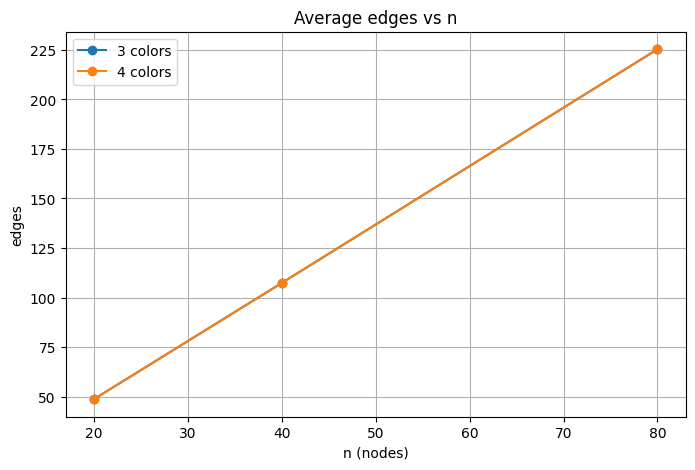

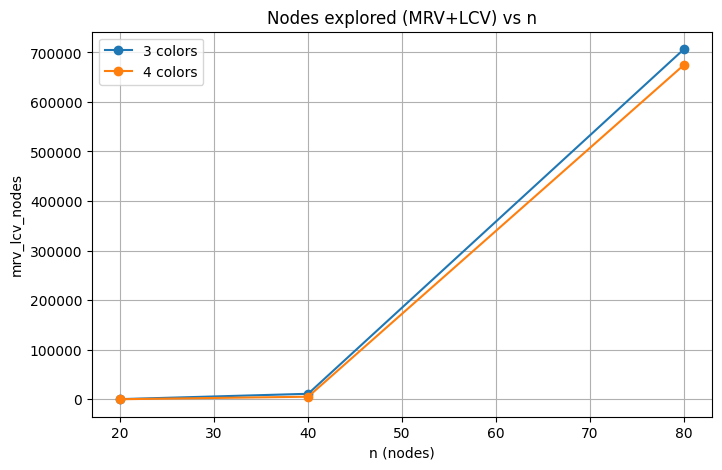

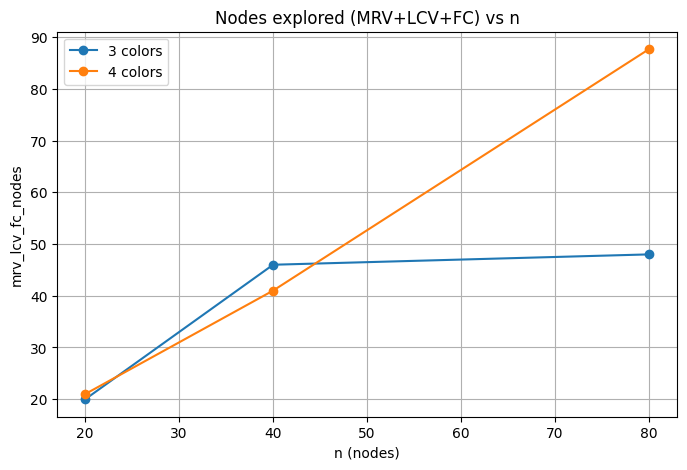

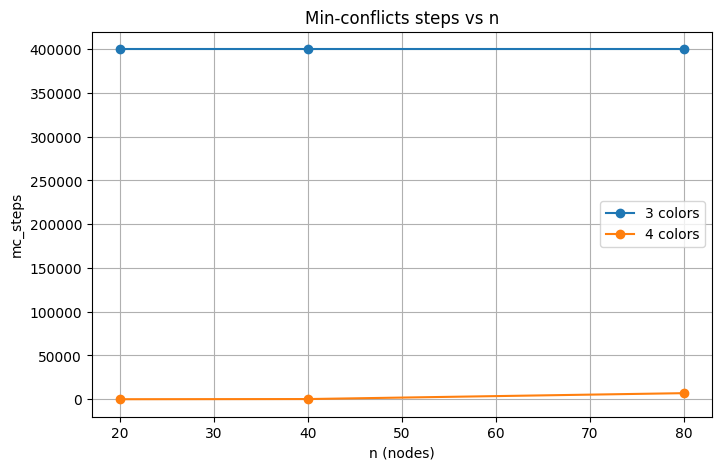

In [ ]:
# ---------- Helper to summarize and plot ----------
def summarize_results(results):
    import pandas as pd
    df = pd.DataFrame(results)
    # group by n and colors
    grouped = df.groupby(['n', 'colors']).agg({
        'edges': 'mean',
        'base_nodes': ['mean', 'median', 'std'],
        'mrv_lcv_nodes': ['mean', 'median'],
        'mrv_lcv_fc_nodes': ['mean', 'median'],
        'mc_steps': ['mean', 'median'],
        'mc_restarts': ['mean']
    })
    pd.set_option('display.width', 200)
    print(grouped)
    return df

def plot_metric(df, metric, title=None):
    groups = df.groupby(['n', 'colors'])[metric].mean().reset_index()
    plt.figure(figsize=(8,5))
    for colors in sorted(groups['colors'].unique()):
        sub = groups[groups['colors']==colors]
        plt.plot(sub['n'], sub[metric], marker='o', label=f'{colors} colors')
    plt.xlabel('n (nodes)')
    plt.ylabel(metric)
    if title: plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# ---------- Example main ----------
if __name__ == "__main__":
    # quick demo parameters (tweak for full experiments)
    n_list = [20, 40, 80]     # values of n to test
    instances_per_n = 3
    colors_list = [3, 4]
    res = run_experiment(n_list, instances_per_n=instances_per_n, colors_list=colors_list, seed_base=42, verbose=True)
    df = summarize_results(res)
    plot_metric(df, 'edges', 'Average edges vs n')
    plot_metric(df, 'mrv_lcv_nodes', 'Nodes explored (MRV+LCV) vs n')
    plot_metric(df, 'mrv_lcv_fc_nodes', 'Nodes explored (MRV+LCV+FC) vs n')
    plot_metric(df, 'mc_steps', 'Min-conflicts steps vs n')